# **Loading the Dataset into Jupyter**

## Mounting from GDrive

In [ ]:
from google.colab import drive
drive.mount('/content/drive') # mounting Google Drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Importing Dataset via Pandas

In [ ]:
import pandas as pd
import numpy as np
Path = '<path_to_file>/training-data_cutdown.xlsx'
loaded_data = pd.read_excel(Path) # Excel File

## Checking the content

In [ ]:
loaded_data.isnull().sum() # checks if there is null value

,0
PatientId,0
Age,0
ChronicDiseaseCount,0
LengthOfStay,0
TotalVisits,0
TotalMedicine,0
CardiacTroponin,0
Hemoglobin,0
SerumSodium,0
SerumCreatinine,0


In [ ]:
print(len(loaded_data))
loaded_data.head() # checks the first five rows

8481


,PatientId,Age,ChronicDiseaseCount,LengthOfStay,TotalVisits,TotalMedicine,CardiacTroponin,Hemoglobin,SerumSodium,SerumCreatinine,ReadmissionWithin_90Days
0,4200412,58,18,3,45,0,0.0,0.00,0.0,0.00,Yes
1,4055894,80,24,6,13,8,0.0,0.00,0.0,1.54,No
2,4867407,63,11,8,5,2,0.0,10.20,0.0,0.00,No
3,4058064,73,8,4,12,0,0.0,0.00,132.0,0.00,No
4,4150623,85,20,3,13,0,0.0,7.26,0.0,0.00,No


# **Logistic Regression Model**

This is the suitable model for binary classification (readmission or not after 90 days).

## Setting up

**Steps:**

*   Install scikit-learn
*   Import pandas, and tools from scikit-learn



In [ ]:
!pip install scikit-learn

In [ ]:
import pandas as pd
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Instantiating columns

This is to put the columns into categories

In [ ]:
col_data = ['ChronicDiseaseCount',	'LengthOfStay',	'TotalVisits', 'TotalMedicine',	'CardiacTroponin',	'Hemoglobin',	'SerumSodium',	'SerumCreatinine']
print(len(col_data))

X = loaded_data[col_data]
y = loaded_data['ReadmissionWithin_90Days']

print(X)
print(y)

8
      ChronicDiseaseCount  LengthOfStay  TotalVisits  TotalMedicine  \
0                      18             3           45              0   
1                      24             6           13              8   
2                      11             8            5              2   
3                       8             4           12              0   
4                      20             3           13              0   
...                   ...           ...          ...            ...   
8476                   14            21            7              6   
8477                   13            19            4              0   
8478                    2            12            2              1   
8479                   19             3            6              5   
8480                    8             2            2              0   

      CardiacTroponin  Hemoglobin  SerumSodium  SerumCreatinine  
0                 0.0        0.00          0.0         0.000000  
1            

## Data Preparation

Separating the dataset to 7:3.

70% of the data is for training, while 30% is for testing.

Then X will be converted to numerical data to avoid possible erros.

In [ ]:
# 70% for training, 30% for testing
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=42)

# Conversion
for col in col_data:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

print(X_train)
print(X_test)

      ChronicDiseaseCount  LengthOfStay  TotalVisits  TotalMedicine  \
6394                   13            20           13              2   
1161                   10             1            1              0   
3693                    9             6            7              0   
7173                   12             2            9              0   
8227                   13             5            5              6   
...                   ...           ...          ...            ...   
5734                   11             5           24              0   
5191                   16             3            6              3   
5390                   10             8           15              2   
860                    14             8            4              0   
7270                   13             3            6              5   

      CardiacTroponin  Hemoglobin  SerumSodium  SerumCreatinine  
6394              0.0       0.000          0.0         0.784286  
1161           

## Creating the Logistic Regression model and make predictions

In [ ]:
model = LogisticRegression(max_iter=1000) # Because there are too many data
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred)

# For checking purposes
count_no = 0
count_yes = 0

for j in y_pred:
  if (j == 'No'):
    count_no += 1
  else:
    count_yes += 1

print("Count of predicted no: " + str(count_no))
print("Count of predicted yes: " + str(count_yes))

['No' 'No' 'No' ... 'No' 'No' 'No']
Count of predicted no: 2359
Count of predicted yes: 186


## Evaluating the model

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
cf_matrix_norm = confusion_matrix(y_test, y_pred, normalize='all')
cf_matrix = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix (Normalized):")
print(cf_matrix_norm)
print("\nConfusion Matrix:")
print(cf_matrix)

Accuracy: 0.7080550098231827

Classification Report:
              precision    recall  f1-score   support

          No       0.72      0.95      0.82      1776
         Yes       0.57      0.14      0.22       769

    accuracy                           0.71      2545
   macro avg       0.64      0.55      0.52      2545
weighted avg       0.67      0.71      0.64      2545


Confusion Matrix (Normalized):
[[0.66640472 0.03143418]
 [0.26051081 0.04165029]]

Confusion Matrix:
[[1696   80]
 [ 663  106]]


## Visualizing the Results

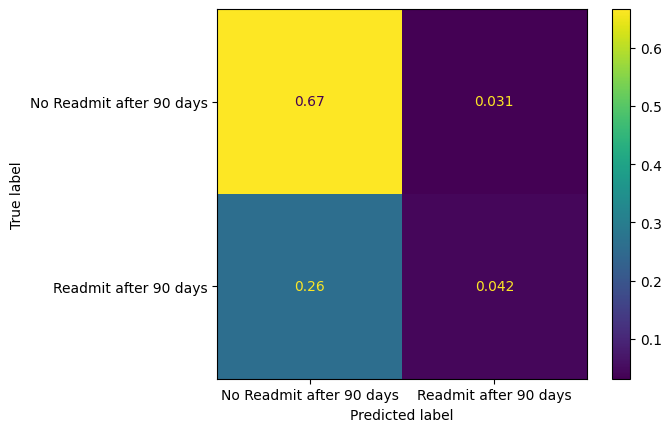

In [ ]:
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
cmd = ConfusionMatrixDisplay(cf_matrix_norm, display_labels=['No Readmit after 90 days', 'Readmit after 90 days'])
cmd.plot()